In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
import math
import numpy as np 
import nibabel as nib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.ndimage import zoom 
import cv2
#from skimage.measure import compare_ssim as ssim # scikit-image==0.14.2 
from skimage.metrics import structural_similarity as ssim
from scipy.fftpack import dct, idct

# data preprocess method

In [96]:
# X_normalized = X - min / max - min
def normalize(snr20, snr40, snrinfinite):
  ma_20 = np.max(snr20)
  mi_20 = np.min(snr20)
  n_snr20 = 255*(snr20-mi_20)/(ma_20-mi_20)
  ma_40 = np.max(snr40)
  mi_40 = np.min(snr40)
  n_snr40 = 255*(snr40-mi_40)/(ma_40-mi_40)
  ma_gt = np.max(snrinfinite)
  mi_gt = np.min(snrinfinite)
  n_snrgt = 255*(snrinfinite-mi_gt)/(ma_gt-mi_gt)
  return n_snr20, n_snr40, n_snrgt

# mask-off the brain, eliminate background noise
def mask_off(mask, n_snr20, n_snr40, n_snrgt):
  mo_snr20 = n_snr20.copy()
  mo_snr40 = n_snr40.copy()
  mo_snrgt = n_snrgt.copy()

  mask_zoom = zoom(mask,(2,2,2))
  mask_zoom[mask_zoom<0.5]=0
  mask_zoom[mask_zoom>0.5]=1

  mo_snr20[mask_zoom==0] = 0.
  mo_snr40[mask_zoom==0] = 0.
  mo_snrgt[mask_zoom==0] = 0.

  return mask_zoom, mo_snr20, mo_snr40, mo_snrgt

# PCA method

In [ ]:
def img2pca(patch_size, image_2D):
  x_size, y_size = image_2D.shape
  pca=[]
  for i in range(x_size-patch_size+1):
    for j in range(y_size-patch_size+1):
      patch = []
      for z1 in range(patch_size):
        k=i+z1
        for z2 in range(patch_size):
          patch.append(image_2D[k,j+z2])

      pca.append(patch)                                                                 

  return np.array(pca)

def pca2img(image_size, pca):
  x_size, y_size = image_size
  patch_size, feature = pca.shape
  feature_size = int(math.sqrt(feature))
  img = np.zeros(image_size)
  img_weight = np.zeros(image_size)

  count_x = 0
  count_y = 0
  count = 0
  for i in range(patch_size):
    for k in range(feature_size):
      for j in range(feature_size):
        if count == feature_size*feature_size*(y_size-feature_size+1):
          count_x += 1
          count = 0
        count += 1
        if count_y == y_size-feature_size+1:
          count_y = 0
        img[k+count_x,j+count_y] += pca[i,k*feature_size+j]
        img_weight[k+count_x,j+count_y] +=1
    
    count_y += 1
  return img/img_weight    

def PCA_denoise(patch_size, k, img_in):

  # change image to pca input data
  # collect each patch in image with size patch_size * patch_size 
  # (eg. if patch_size is 3, collect each 3*3 matrix as a single patch in image)
  # in pca form data, each row is a patch that reshape from (patch_size,patch_size) to (patch_size^2,1)
  # column quantity of pca input data is the patch quantity in image
  pca_raw = img2pca(patch_size, img_in)
  img = pca_raw.copy() 

  # use PCA to drop (patch_size - k) eignvector
  pca = PCA(n_components = k)
  pca.fit(img)
  Z = pca.transform(img)
  pca_image = pca.inverse_transform(Z)  

  # change back to image form
  img_out = pca2img(img_in.shape, pca_image)

  return img_out

# tune p and patch size method(炼丹)



In [155]:
def p_snr(img,gt,mask):
  MSE = np.sum((img-gt)**2)/np.sum(mask)
  snr = 10*np.log10(np.max(img)**2/MSE)
  return snr  

In [156]:
def evaluate_PCA_k(img_gt, img_20, img_40, img_mask, patch_size):
  print("Before PCA denoise: ssim={}, psnr={}, psnr2={}".format(ssim(img_20, img_gt), cv2.PSNR(img_20, img_gt), p_snr(img_20,img_gt,img_mask)))
  for k in range(1,patch_size*patch_size):
    img_20_out = PCA_denoise(patch_size,k,img_20)
    #img_40_out = PCA_denoise(patch_size,k,img_40)
    print("k={}: ssim={}, psnr={}, psnr2={}".format(k,ssim(img_20_out, img_gt),cv2.PSNR(img_20_out, img_gt),p_snr(img_20_out,img_gt,img_mask)))

def evaluate_PCA_patch(img_gt, img_20, img_40, img_mask, patch_range):
  print("patch range from 2 to {}".format(patch_range))
  for i in range(2,patch_range+1):
    print("patch size = {}".format(i))
    evaluate_PCA_k(img_gt, img_20, img_40, img_mask, i)

# data preprocess

In [119]:
data_path = '/content/gdrive/MyDrive/code/523/data'
os.path.isdir(data_path)

True

In [120]:
mask = nib.load(os.path.join(data_path, "mask.nii")).get_fdata()
snr20 = nib.load(os.path.join(data_path, "t2_snr20_b0space.nii")).get_fdata()
snr40 = nib.load(os.path.join(data_path, "t2_snr40_b0space.nii")).get_fdata()
snrinfinite = nib.load(os.path.join(data_path, "t2_snrinfinite_b0space.nii")).get_fdata()

In [121]:
n_snr20, n_snr40, n_snrgt = normalize(snr20, snr40, snrinfinite)
mask_zoom, mo_snr20, mo_snr40, mo_snrgt = mask_off(mask, n_snr20, n_snr40, n_snrgt)

# data visualize

In [123]:
idx = 5

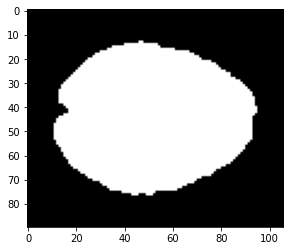

In [124]:
img_mask = mask[:,:,45]
plt.imshow(img_mask,cmap='gray')

Orignial data

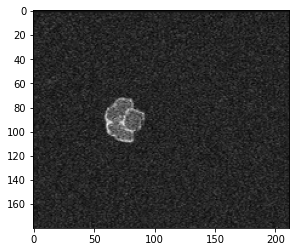

In [125]:
img_od_noised = snr20[:,:,idx]
plt.imshow(img_od_noised,cmap='gray')

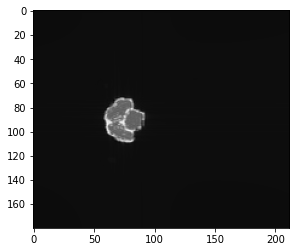

In [126]:
img_od_gt = snrinfinite[:,:,idx]
plt.imshow(img_od_gt,cmap='gray')

after normalize

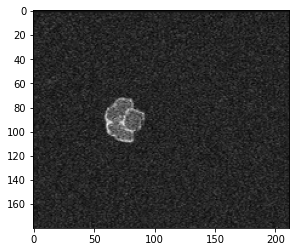

In [127]:
img_an_noised = n_snr20[:,:,idx]
plt.imshow(img_an_noised,cmap='gray')

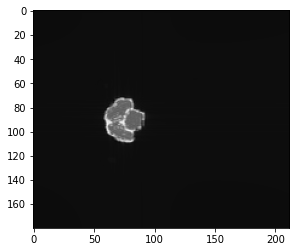

In [128]:
img_an_gt = n_snrgt[:,:,idx]
plt.imshow(img_an_gt,cmap='gray')

after mask-off

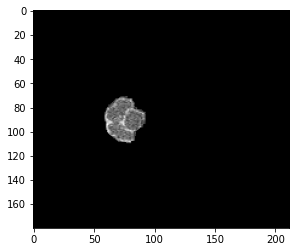

In [129]:
img_am_noised = mo_snr20[:,:,idx]
plt.imshow(img_am_noised,cmap='gray')

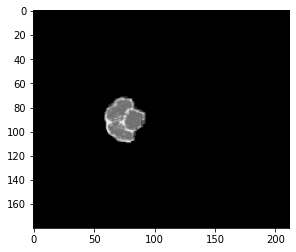

In [130]:
img_am_gt = mo_snrgt[:,:,idx]
plt.imshow(img_am_gt,cmap='gray')

after PCA

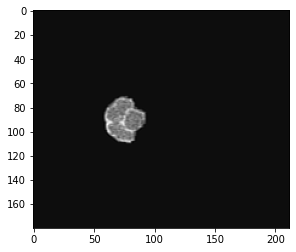

In [131]:
img_out = PCA_denoise(3, 5, img_am_noised)
plt.imshow(img_out,cmap='gray')

evaluate

In [132]:
ssim(img_am_gt, img_am_noised)

0.9949322063873212

In [133]:
ssim(img_am_gt, img_out)

0.9852618799317041

In [134]:
cv2.PSNR(img_am_gt, img_am_noised)

39.08127355831287

In [135]:
cv2.PSNR(img_am_gt, img_out)

39.09079103385059

# run (炼丹)

In [157]:
i=90
img_gt = mo_snrgt[:,:,i]
img_20 = mo_snr20[:,:,i]
img_40 = mo_snr40[:,:,i]
img_mask = mask_zoom[:,:,i]

In [158]:
evaluate_PCA_patch(img_gt, img_20, img_40, img_mask, 5)

patch range from 2 to 5
patch size = 2
Before PCA denoise: ssim=0.7811013038387832, psnr=26.566239375627386, psnr2=21.96366394619856
k=1: ssim=0.785682472344167, psnr=27.170074569051774, psnr2=21.186867703887955
k=2: ssim=0.7868068545504603, psnr=27.46384473149185, psnr2=22.257610979151906
k=3: ssim=0.7739233743291846, psnr=27.270855502886103, psnr2=22.384807694626865
patch size = 3
Before PCA denoise: ssim=0.7811013038387832, psnr=26.566239375627386, psnr2=21.96366394619856
k=1: ssim=0.7074964828307558, psnr=25.537702044383934, psnr2=18.98789044092092
k=2: ssim=0.7285544470183348, psnr=26.947016212298216, psnr2=20.94621910031369
k=3: ssim=0.7344974510055424, psnr=27.72776321466356, psnr2=22.23519697177462
k=4: ssim=0.7337271995662367, psnr=27.78348040823426, psnr2=22.594069184795128
k=5: ssim=0.7527326907682487, psnr=27.61302690510471, psnr2=22.73809109748781
k=6: ssim=0.7568596291006098, psnr=27.250770558918905, psnr2=22.450829307816296
k=7: ssim=0.7567788774884235, psnr=27.067938152

# dct

In [77]:
def patch2dct(patch, patch_size):

  patchs = np.zeros((patch_size, patch_size))
  for i in range(patch_size):
    for j in range(patch_size):
      patchs[i,j] = patch[i*patch_size+j]

  DCT = dct(dct(patchs.T, norm='ortho').T, norm='ortho')
  return DCT

def dct2patch(DCT, patch_size):
  DCTs = idct(idct(DCT.T, norm='ortho').T, norm='ortho')

  patch = np.zeros(patch_size * patch_size)
  for i in range(patch_size):
    for j in range(patch_size):
      patch[i*patch_size+j] = DCTs[i,j]

  return patch

def DCT_denoise(patch_size, keepRow, keepCol, img_in):
  dct_raw = img2pca(patch_size, img_in)

  # dct
  DCT = []
  for i in range(dct_raw.shape[0]):
    patch_dct = patch2dct(dct_raw[i], patch_size)
    patch_dct[keepRow:patch_size, keepCol:patch_size] = 0
    newPatch = dct2patch(patch_dct, patch_size)
    DCT.append(newPatch)

  # change back to image form
  img_out = pca2img(img_in.shape, np.array(DCT))

  return img_out  

In [168]:
def evaluate_DCT_keep(img_gt, img_20, img_40, img_mask, patch_size):
  print("Before DCT denoise: ssim={}, psnr={}, psnr2={}".format(ssim(img_20, img_gt), cv2.PSNR(img_20, img_gt), p_snr(img_20,img_gt,img_mask)))
  for i in range(1,patch_size-1):
      img_20_out = DCT_denoise(patch_size,i,i+1,img_20)
      #img_40_out = DCT_denoise(patch_size,i,i+1,img_40) 
      print("keep row={}, keep col={}, ssim={}, psnr={}, psnr2={}".format(i,i+1,ssim(img_20_out, img_gt), cv2.PSNR(img_20_out, img_gt), p_snr(img_20_out,img_gt,img_mask)))

def evaluate_DCT_patch(img_gt, img_20, img_40, img_mask, patch_range):
  print("patch range from 3 to {}".format(patch_range))
  for i in range(3,patch_range+1):
    print("patch size = {}".format(i))
    evaluate_DCT_keep(img_gt, img_20, img_40, img_mask, i)

In [162]:
i=90
img_gt = mo_snrgt[:,:,i]
img_20 = mo_snr20[:,:,i]
img_40 = mo_snr40[:,:,i]
img_mask = mask_zoom[:,:,i]

In [169]:
evaluate_DCT_patch(img_gt,img_20,img_40,img_mask,8)

patch range from 3 to 8
patch size = 3
Before DCT denoise: ssim=0.7811013038387832, psnr=26.566239375627386, psnr2=21.96366394619856
keep row=1, keep col=2, ssim=0.7574843867014327, psnr=27.11169901444734, psnr2=22.356405230304603
patch size = 4
Before DCT denoise: ssim=0.7811013038387832, psnr=26.566239375627386, psnr2=21.96366394619856
keep row=1, keep col=2, ssim=0.7489044630767665, psnr=27.454634622701057, psnr2=22.419392534624585
keep row=2, keep col=3, ssim=0.7479733174064062, psnr=26.82804779389727, psnr2=22.22508704400521
patch size = 5
Before DCT denoise: ssim=0.7811013038387832, psnr=26.566239375627386, psnr2=21.96366394619856
keep row=1, keep col=2, ssim=0.7362196699829539, psnr=27.505252058989107, psnr2=22.315541319429823
keep row=2, keep col=3, ssim=0.7396440577941183, psnr=27.133292554151545, psnr2=22.325140598937754
keep row=3, keep col=4, ssim=0.7417130172454488, psnr=26.70495658978144, psnr2=22.143024535597206
patch size = 6
Before DCT denoise: ssim=0.7811013038387832,

In [103]:
img_out1 = DCT_denoise(8,2,3,img_20)
img_out2 = DCT_denoise(8,3,4,img_20)

In [106]:
p_snr(img_20,img_gt,img_mask)

21.96366394619856

In [107]:
p_snr(img_out1,img_gt,img_mask)

22.360411142923713

In [108]:
p_snr(img_out2,img_gt,img_mask)

22.288679889938535

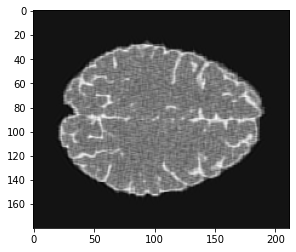

In [109]:
plt.imshow(img_out1,cmap='gray')

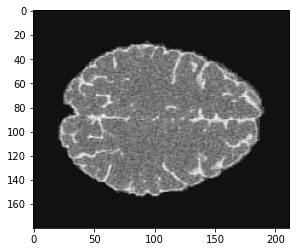

In [110]:
plt.imshow(img_out2,cmap='gray')

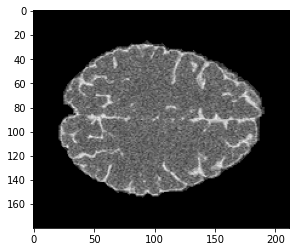

In [111]:
plt.imshow(img_20,cmap='gray')